In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from efficient_kan import KAN

os.makedirs("figures", exist_ok=True)


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from efficient_kan import KAN

os.makedirs("figures", exist_ok=True)

# Parámetros analíticos del problema
alpha = 0.5
beta = 5.0

def target_function(x):
    return np.exp(-alpha * x**2) * np.cos(beta * x)

# 1. Datos de entrenamiento en el dominio acotado [-5, 5]
X_train_np = np.linspace(-5, 5, 150, dtype=np.float32)
Y_train_np = target_function(X_train_np)
X_train = torch.tensor(X_train_np).unsqueeze(1)
Y_train = torch.tensor(Y_train_np).unsqueeze(1)

# 2. Dominio de evaluación extendido [-50, 50]
X_eval_np = np.linspace(-50, 50, 800, dtype=np.float32)
Y_eval_np = target_function(X_eval_np)
X_eval = torch.tensor(X_eval_np).unsqueeze(1)

# 3. Definir y entrenar MLP (Activación global Tanh)
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

mlp = SimpleMLP()
optimizer_mlp = optim.Adam(mlp.parameters(), lr=0.01)
criterion = nn.MSELoss()

mlp.train()
for epoch in range(2000):
    optimizer_mlp.zero_grad()
    loss = criterion(mlp(X_train), Y_train)
    loss.backward()
    optimizer_mlp.step()

mlp.eval()
with torch.no_grad():
    Y_mlp_pred = mlp(X_eval).numpy().flatten()

# 4. Definir y entrenar Efficient-KAN
# layers_hidden define la estructura de capas de la KAN
kan = KAN(layers_hidden=[1, 16, 1], grid_size=5, spline_order=3)
optimizer_kan = optim.Adam(kan.parameters(), lr=0.01)

kan.train()
for epoch in range(2000):
    optimizer_kan.zero_grad()
    loss = criterion(kan(X_train), Y_train)
    loss.backward()
    optimizer_kan.step()

kan.eval()
with torch.no_grad():
    Y_kan_pred = kan(X_eval).numpy().flatten()
 

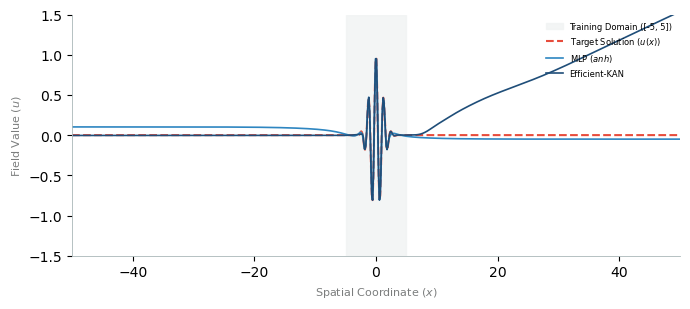

Figure successfully saved to figures/efficient_kan_extrapolation.pdf


In [10]:

# =========================================================
# Plotting Results
# =========================================================
palette = {
    "kan": "#1f4e79",
    "mlp": "#2e86c1",
    "true": "#e74c3c",
    "text_muted": "#7b7d7d",
    "spine": "#aab7b8"
}
fig, ax = plt.subplots(figsize=(7, 3.2))

# Región de entrenamiento
ax.axvspan(-5, 5, color='#f2f4f4', alpha=0.9, label='Training Domain ([-5, 5])')

ax.plot(X_eval_np, Y_eval_np, color=palette["true"], linestyle='--', lw=1.5, label='Target Solution ($u(x)$)')
ax.plot(X_eval_np, Y_mlp_pred, color=palette["mlp"], linestyle='-', lw=1.2, label='MLP ($\tanh$)')
ax.plot(X_eval_np, Y_kan_pred, color=palette["kan"], linestyle='-', lw=1.2, label='Efficient-KAN')

ax.set_xlim(-50, 50)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Spatial Coordinate ($x$)", fontsize=8, color=palette["text_muted"])
ax.set_ylabel("Field Value ($u$)", fontsize=8, color=palette["text_muted"])
ax.legend(frameon=False, fontsize=6, loc="upper right")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine_name in ['bottom', 'left']:
    ax.spines[spine_name].set_color(palette["spine"])
    ax.spines[spine_name].set_linewidth(0.6)

plt.tight_layout()
fig_path = "figures/efficient_kan_extrapolation.pdf"
plt.savefig(fig_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Figure successfully saved to {fig_path}")